---
title: Mean Modelling Results
date: 11/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

In this notebook, we process and interpret the results of fitting our models for average snowfall and average temperature outcomes.

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
import json
import sys
import shap

sys.path.append('../scripts')
from model_fitting.xgboost.interpretation_utils_xgb import *
from model_fitting.xgboost.cv_utils_xgb import predictive_r2
from plotting_utils import *

# constants fot plotting
from abbreviations_units import ABBV_DICT, UNITS_DICT

/scratch/users/butlerj/conda/envs/extreme_antarctic_ars_python/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/scratch/users/butlerj/conda/envs/extreme_antarctic_ars_python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cumulative Snowfall

First, let's grab the optimal hyperparameters we found via 5-fold cross validation.

In [2]:
with open('../auxiliary_files/hyperparam_dictionaries/xgboost/best_snow_xgb.json', 'r') as file:
        best_snow = json.load(file)

In [3]:
best_snow

{'gamma': 0.0075,
 'max_depth': 3.0,
 'reg_lambda': 0.75,
 'min_child_weight': 5.0,
 'subsample_frac': 0.9,
 'eta': 0.075,
 'num_boost': 123.0,
 'shrinkage_factor': 1.0018205032}

In [4]:
# creating the dictionary of hyperparameters for training

hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_snow['gamma'])
hyperparam_dict['max_depth'] = int(best_snow['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_snow['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_snow['min_child_weight'])
hyperparam_dict['subsample_frac'] = float(best_snow['subsample_frac'])
hyperparam_dict['eta'] = float(best_snow['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_snow['num_boost'])
shrinkage_factor = best_snow['shrinkage_factor']

In [5]:
# creating training and test data objects

train_data = pd.read_csv('../outputs/data_products/train.csv', index_col='Label')
test_data = pd.read_csv('../outputs/data_products/test.csv', index_col='Label')
y_col = 'cumulative_snowfall_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 
          'avg_landfalling_minomega', 'max_IWV_ais', 
          'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
X_test = test_data[x_cols]
y_test = test_data[y_col]
y_train_centered = y_train - y_train.mean()
y_test_centered = y_test - y_train.mean()

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

In [6]:
# training linear regression on CLA to obtain residuals

linreg = LinearRegression(fit_intercept=False)
x_cla_mean = X_train['cumulative_landfalling_area'].mean()
x_cla_centered = X_train['cumulative_landfalling_area'] - x_cla_mean
linear_fit = linreg.fit(X=pd.DataFrame(x_cla_centered), y=y_train_centered)
resid = y_train_centered - linear_fit.predict(pd.DataFrame(x_cla_centered))

While we're here, let's just look for a quick second at the mean-centered outcome distribution, as well as the residual distribution. We are fitting XGBoost to the residuals as the outcome. It seems there are a few outliers, but that the outliers are more symmetric. Outliers may pose a challenge for XGBoost, especially since we are using squared error as our loss function to build our trees. However, since we performed 5-fold CV across hyperparameters that can reduce the impact of outliers, we hope their impact is diminished.

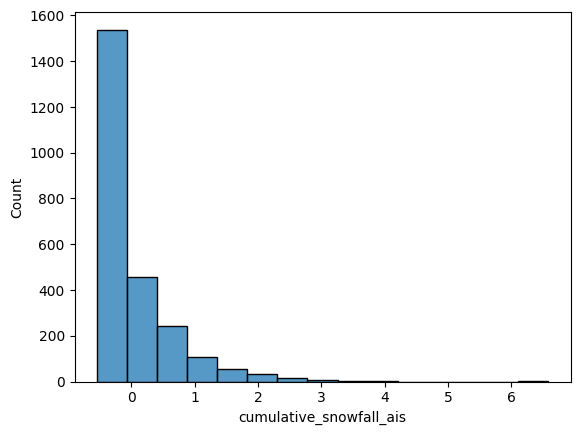

In [7]:
sns.histplot(y_train_centered, bins=15);

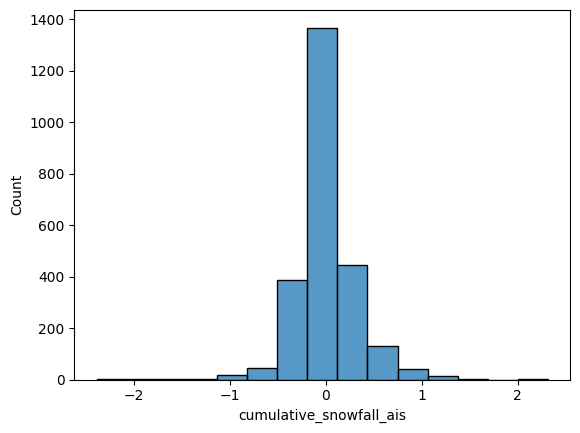

In [8]:
sns.histplot(resid, bins = 15);

In [9]:
# training the residual model

model_snow = xgb.XGBRegressor(n_estimators=num_boost, 
                     max_depth=hyperparam_dict['max_depth'], 
                     learning_rate=hyperparam_dict['eta'],
                     booster=hyperparam_dict['booster'],
                     tree_method=hyperparam_dict['tree_method'],
                     gamma=hyperparam_dict['gamma'],
                     min_child_weight=hyperparam_dict['min_child_weight'],
                     reg_lambda=hyperparam_dict['reg_lambda'],
                     subsample=hyperparam_dict['subsample_frac'],
                     objective='reg:squarederror',
                     eval_metric='rmse',
                     random_state=54321)

resid_fit = model_snow.fit(X_train, resid)

In [10]:
def prediction_snow(X, y_train, linear_fit, resid_fit, shrinkage_factor, centered=False):
    pred = shrinkage_factor*(resid_fit.predict(X) + 
                      linear_fit.predict(pd.DataFrame(X['cumulative_landfalling_area'] - x_cla_mean)))

    if not centered:
        return pred + y_train.mean()

    return pred

In [11]:
y_test_pred = prediction_snow(X_test, y_train, linear_fit, resid_fit, shrinkage_factor)
y_train_pred = prediction_snow(X_train, y_train, linear_fit, resid_fit, shrinkage_factor)

In [12]:
## training predictive r-squared
train_pred_r2 = predictive_r2(y_train_pred, y_train)

## testing predictive r-squared
test_pred_r2 = predictive_r2(y_test_pred, y_test)

## ols baseline
reg = LinearRegression().fit(X_train, y_train_centered)
y_pred_ols = reg.predict(X_test) + y_train.mean()
test_ols_r2 = predictive_r2(y_pred_ols, y_test)

Now, let's analyze model performance on the held-out test set.

In [13]:
train_res = round(float(train_pred_r2), 3)
train_res

0.926

In [14]:
test_res = round(float(test_pred_r2), 3)
test_res

0.875

In [15]:
test_ols = round(float(test_ols_r2), 3)
test_ols

0.816

How much closer did our prediction scheme get us to perfection, relative to OLS?

In [16]:
(test_res - test_ols)/(1-test_ols)

0.3206521739130437

This is pretty good! Our model closed 34% of the gap to perfection that existed with OLS. Now, let's interpret our model output.

First, we look at variable importance metrics by way of permutation scores, where for each variable, we randomly permute the observations in that column and compute how much the error increases. We repeat this multiple times to get an average.

Upon getting a sense of which variables are the most important in predicting snowfall *in the context of this model*, we then further interrogate the model with 1D and 2D partial dependence plots to explore how the model makes predictions when holding other variables fixed.

In [17]:
importances = get_permutation_importance(lambda X: prediction_snow(X, y_train=y_train, linear_fit=linear_fit, resid_fit=resid_fit, shrinkage_factor=shrinkage_factor),
                               X_test, y_test, predictive_r2, maximize=True, n_repeats=500, seed=12345)

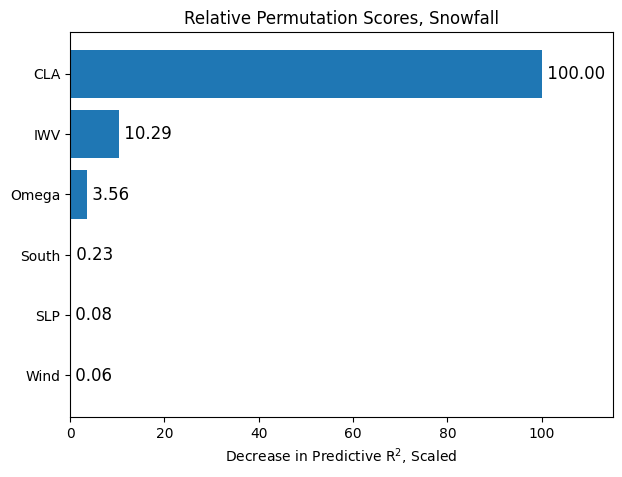

In [18]:
fig, ax = plt.subplots(figsize=(7,5))
tick_labels = [ABBV_DICT[varname] for varname in importances.index]

plot_variable_importance(importances, ax, 'Relative Permutation Scores, Snowfall', tick_labels=tick_labels);

From the results, we see that cumulative landfalling area is by far the most important predictor of snowfall in this model, followed by integrated water vapor, omega, and wind speed. All of these quantites are expressed as percentages of the most important predictor found.

Now, let's first plot and interpret some partial dependence plots. Intuitively, these show how the model behaves as one quantity is varied at a time, holding all else fixed. In other words, it shows the predictive relationship between one variable and the outcome, marginalizing all of the other variables out.

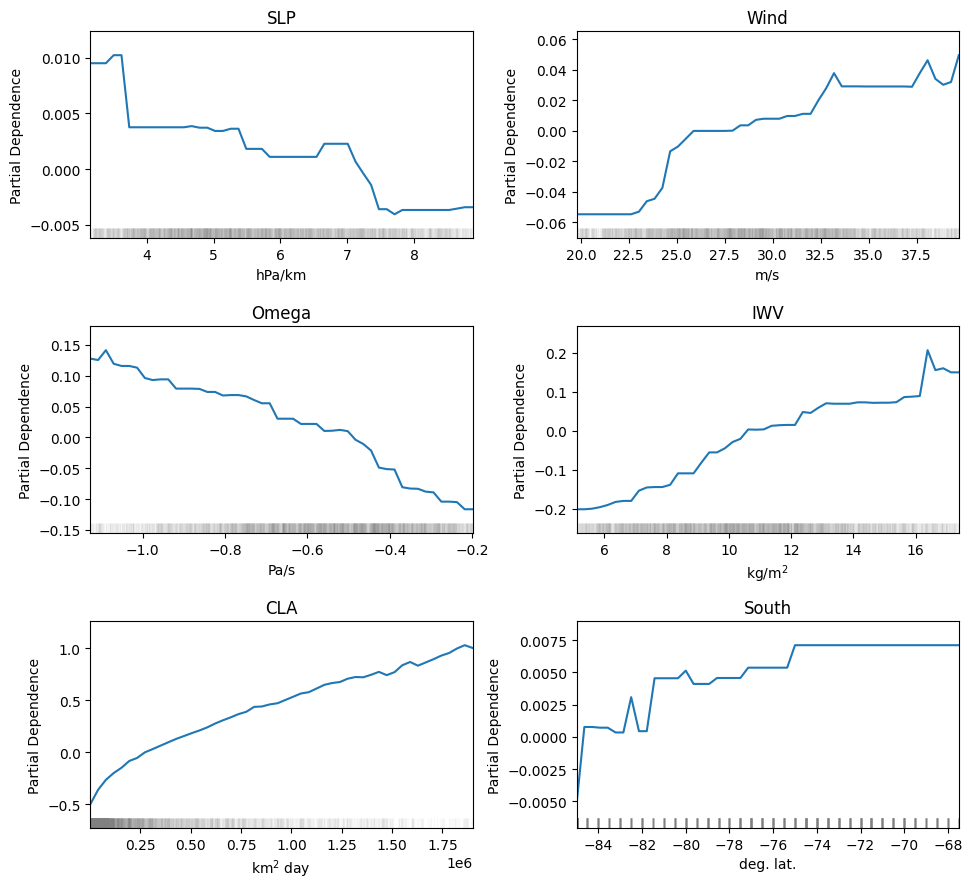

In [19]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 9))
axs = axs.flatten()
features = list(X_full.columns)

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                    extents=extents)

    abbv = ABBV_DICT[features[i]]
    units = UNITS_DICT[features[i]]

    plot_pdp_1d(grid, pdp_vals, ax, feature_values=X_full[features[i]], title=abbv, xlabel=units,
        ylabel='Partial Dependence', xlim=None, rug=True);

plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_1d_pdp.png', dpi=300)

Now, let's isolate the top 4 as far as variable importances go, and plot them on the same set of axes.

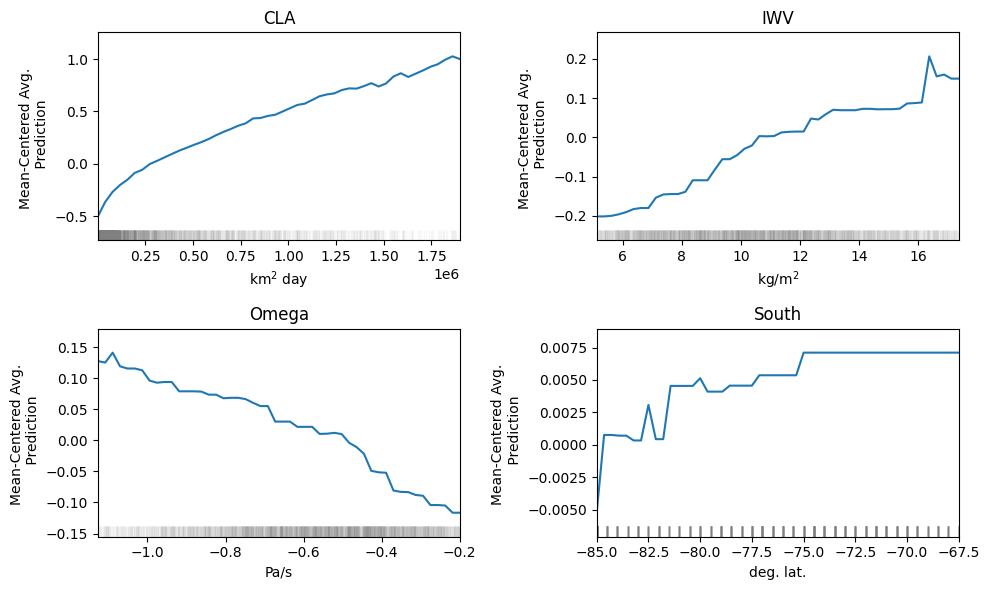

In [20]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
axs = axs.flatten()
features = list(importances.index[0:4]) # top 4 in variable importance

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                    extents=extents)

    abbv = ABBV_DICT[features[i]]
    units = UNITS_DICT[features[i]]
    
    plot_pdp_1d(grid, pdp_vals, ax, feature_values=X_full[features[i]], title=abbv, xlabel=units,
        ylabel='Mean-Centered Avg. \n Prediction', xlim=None, rug=True);

plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_1d_pdp_subset.png', dpi=300)

Interpretation: Holding all other variables fixed, increasing CLA gives the biggest increases in snowfall predictions on average. Increasing IWV leads to higher snowfall predictions, lower omega leads to higher snowfall predictions, and higher wind seems to lead to higher snowfall predictions as well, but the effect of wind on model predictions is much smaller than the other variables.

This is more informative than scatter plots for example, since we are now asking our model to give us predictions varying one of these variables *and holding all other features fixed* to isolate the effect of individual variables on model predictions. CAUTION: this is the effect on *model predictions*, not necessarily real-world effects. Nonetheless, it can still be informative because obviously the model picked up on patterns, and so it can illuminate future routes of study for mechanisms of ARs. 

Now, what if we vary two variables at once and hold all others fixed? This will help illuminate any interactions that our model may have picked up on in the dataset. Maybe the effect of one variable on model predictions depends on the value of another variable? 2D PDPs will be of help here.

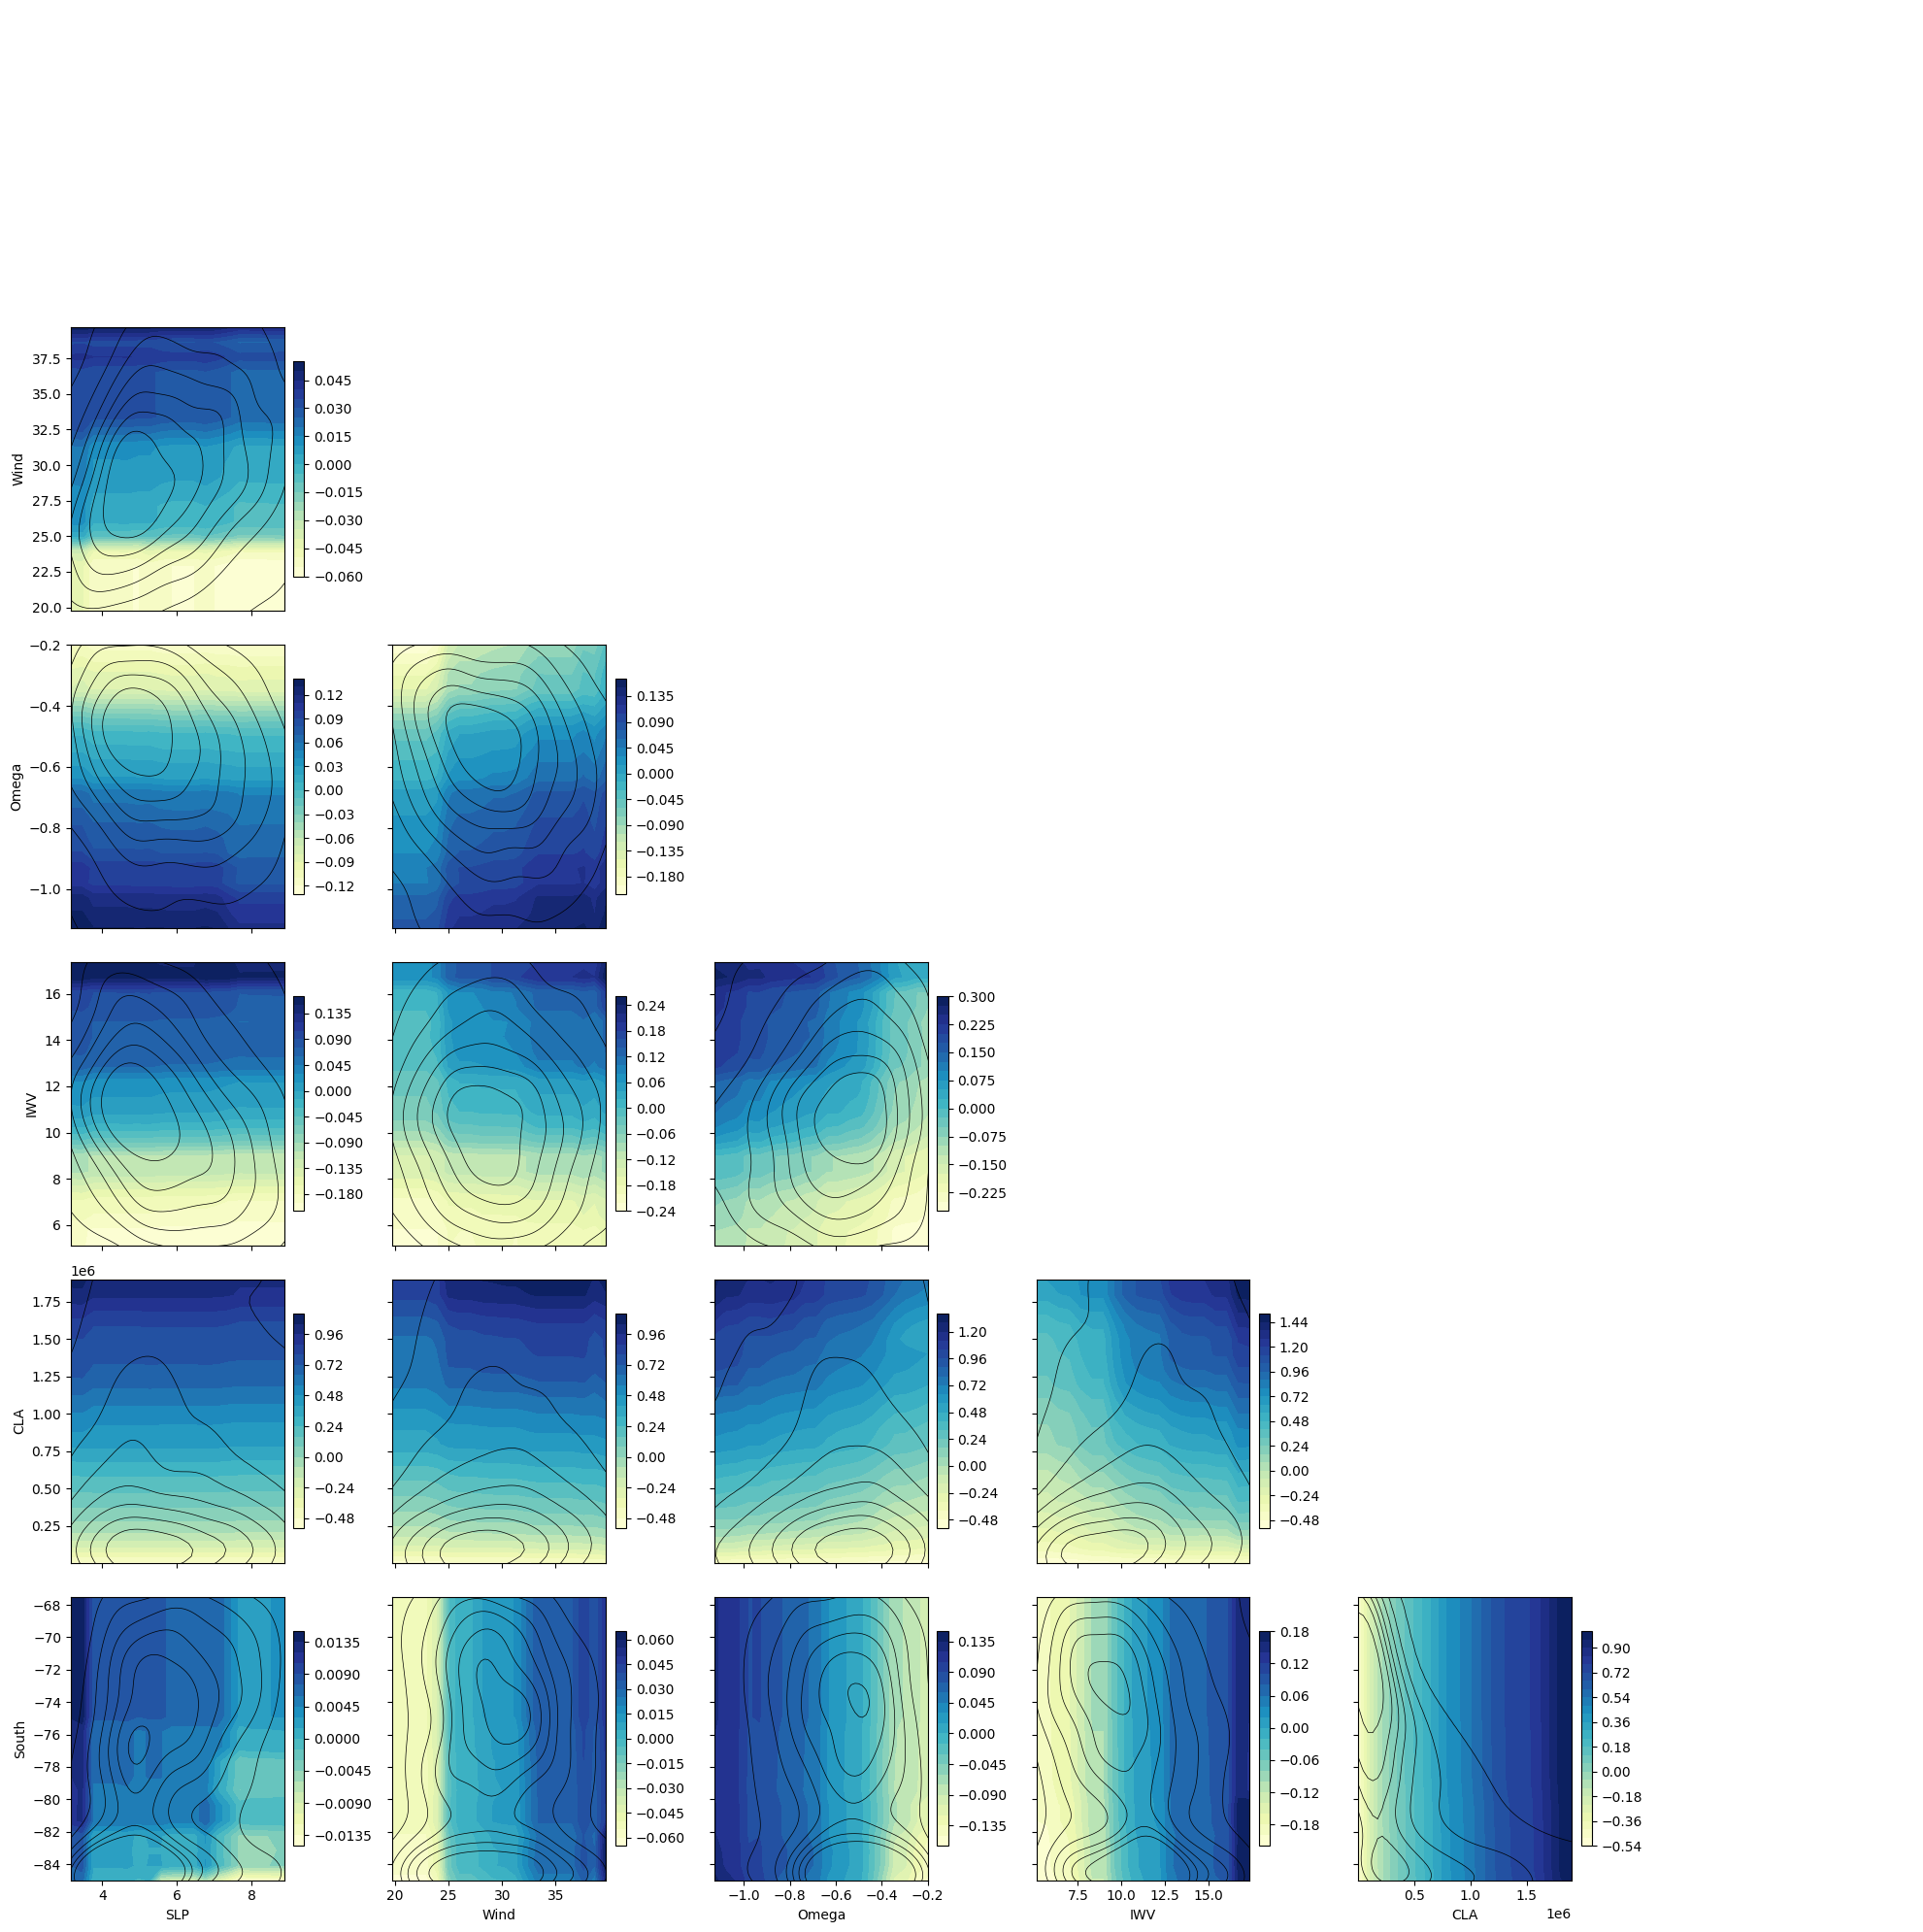

In [21]:
features = X_test.columns
n_features = len(features)

fig, axs = plt.subplots(ncols=n_features, nrows=n_features, figsize=(20, 20))

for i in range(n_features):
    for j in range(n_features):
        ax = axs[i, j]
        
        # Only plot on the lower diagonal (row index > col index)
        if i > j:
            feat_y = features[i]
            feat_x = features[j]

            q = 0.05 # quantile to clip data
            extents = [X_full[feat_x].quantile(q), 
                       X_full[feat_x].quantile(1-q),
                       X_full[feat_y].quantile(q),
                       X_full[feat_y].quantile(1-q)]

            grid1, grid2, pdp_matrix = compute_pdp_2d(
                feat_x, feat_y, 
                X_full, 
                lambda X: prediction_snow(X, 
                                          y_train=y_train, 
                                          linear_fit=linear_fit,
                                          resid_fit=resid_fit,
                                          shrinkage_factor=shrinkage_factor,
                                          centered=True),
                extents=extents)

            ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full[feat_x],
                feat_y_values=X_full[feat_y], cmap='YlGnBu', levels=25, kde=True)

            fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

            # standardize labels: x only on bottom row, y only on left column
            if i == n_features - 1:
                ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])

        else:
            ax.axis('off')
            
plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_2d_pdp_full.png', dpi=300);

Below, we choose to isolate interactions between the second most important variable (IWV), and the other three of the four most important variables (by way of the permutation score). Because CLA dominates so heavily, we plot each individual plot's color scale individually so as to highlight more fine-grained detail for other pairs.

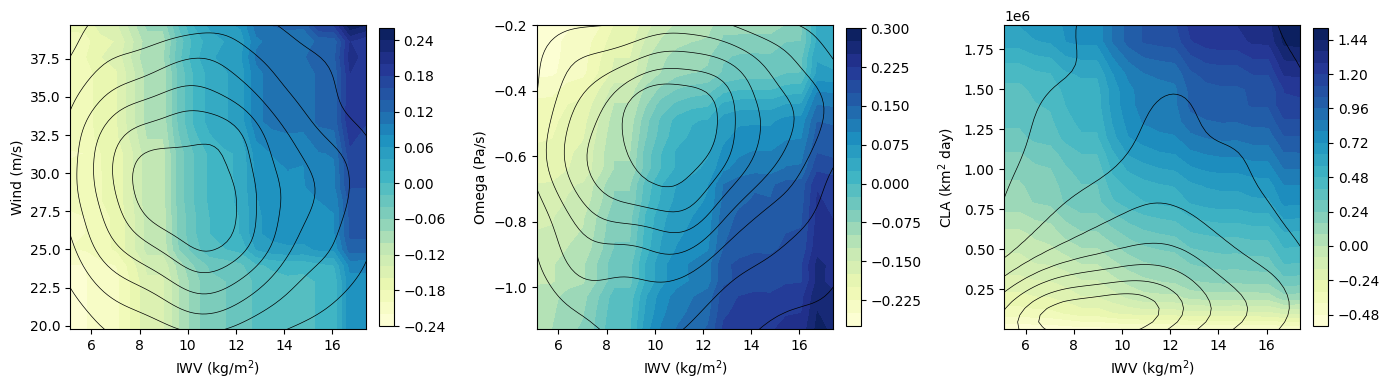

In [22]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(14, 4))

axs = axs.flatten()

combos = [('max_IWV_ais', 'max_landfalling_v850hPa'),
          ('max_IWV_ais', 'avg_landfalling_minomega'),
          ('max_IWV_ais', 'cumulative_landfalling_area')]

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]
    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                             extents=extents)
    x_label = f'{ABBV_DICT[combo[0]]} ({UNITS_DICT[combo[0]]})'
    y_label = f'{ABBV_DICT[combo[1]]} ({UNITS_DICT[combo[1]]})'
    ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full[combo[0]],
                feat_y_values=X_full[combo[1]], xlabel=x_label, ylabel=y_label, cmap='YlGnBu', levels=25, kde=True)

    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout();

plt.savefig('../outputs/plots/mean_snowfall_2d_pdp_subset.png', dpi=300)

Interpretation:
+ (left) holding all other variables fixed, increasing both wind and IWV leads to higher snowfall predictions. However, there are some interesting interactions: for fixed IWV, increasing the wind speed doesn't seem to do much at all for snowfall predictions until we have higher IWV. However, for fixed windspeed, no matter how small, increasing the IWV leads to higher snowfall predictions. This validates what we saw in our bivariate exploratory plots: that high wind-speed is not a necessary condition for increased snowfall. However, as wind-speed increases, the effect of IWV on snowfall predictions increases.
+ (middle) holding all other variables fixed, increasing both IWV and Omega leads to higher snowfall predictions. But it's asymmetric: jacking omega up for small IWV doesn't produce as high snowfall predictions as jacking up IWV for low omega. Similarly, if you fix IWV at a high value, the rate of increase in snowfall predictions is smaller per unit omega, than if we fix omega at a high value and increase moisture content. So, IWV and omega interact to produce snowfall predictions.
+ (right) more moist storms that spend more time over the ice sheet have higher snowfall predictions, holding all other variables constant. Increasing IWV leads to steeper increases in snowfall predictions as CLA increases. And increasing CLA leads to steeper increases in snowfall predictions as IWV increases. You can see that they interact a bit, but that CLA is the dominant force in generating these predictions.

Significance:
+ Moisture dominated ARs have higher snowfall predictions than wind-dominated ARs, and wind-speed only begins to play a role in snowfall predictions with higher IWV storms. However, IWV increases snowfall predictions for all wind speeds, with the increases becoming more steep as wind increases. If a storm is relatively dry, increasing the wind speed doesn't produce as much snowfall, and doesn't lead to nearly as demonstrable increases in snowfall output.
+ Lift interacts with moisture such that the more lifting, the higher the predicted snowfall per unit increase of IWV. Omega clearly plays a bigger role here than wind.


Another tool in our toolkit are SHAP values! SHAP values are useful quantities that help us ascribe predictive influence of individual variables towards predictions. In other words, it gives us a way of divvying up the predictive power for different observations among variables, allowing us to see how much of the total prediction was contributed by each variable. So, it answers a different yet complementary question as the PDPs. Because our snowfall predictions are generated from a model consisting of a linear regression and a tree ensemble, we use the Kernel SHAP method to approximate SHAP values.

In [23]:
FULL_FEATURE_NAMES = X_train.columns

def prediction_snow(X):
    X_df = pd.DataFrame(X, columns=FULL_FEATURE_NAMES)
    pred = y_train.mean() + shrinkage_factor*(resid_fit.predict(X_df) + 
                      linear_fit.predict(pd.DataFrame(X_df.iloc[:, 4] - x_cla_mean)))

    return pred

explainer_full = shap.KernelExplainer(model=prediction_snow, data=X_train)

Using 2466 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [24]:
shap_values = explainer_full.shap_values(X_test)

100%|██████████| 616/616 [01:06<00:00,  9.19it/s]


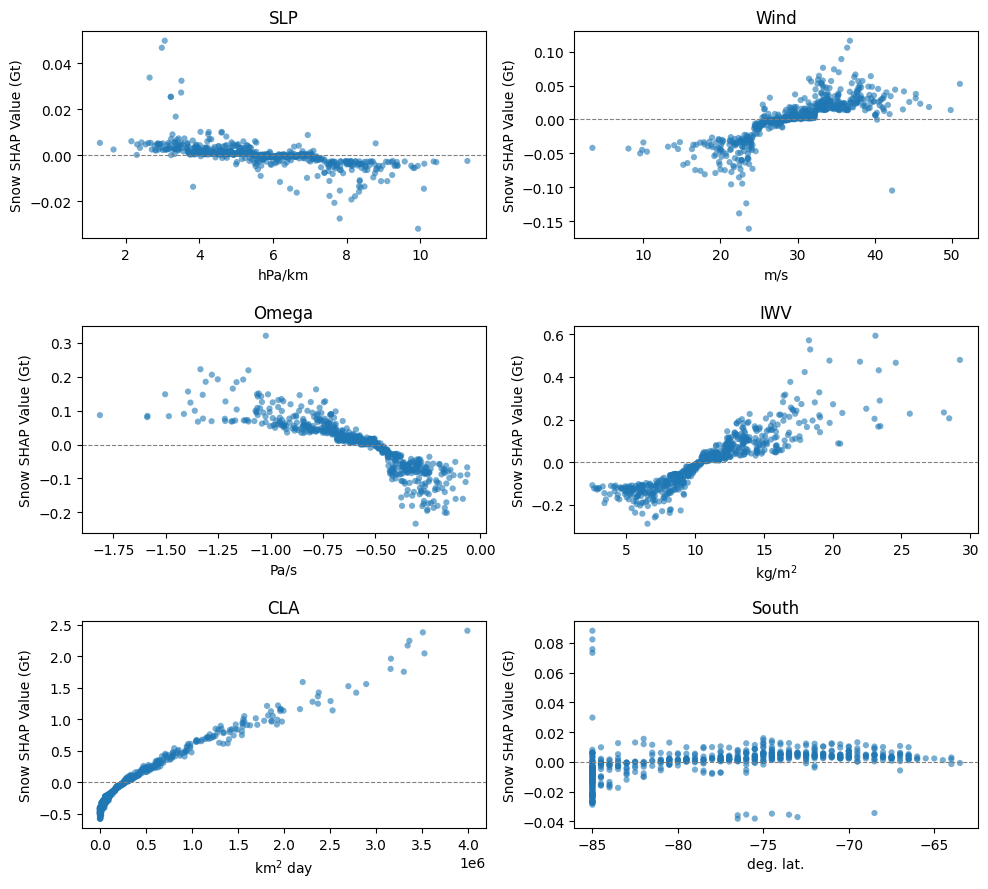

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
feature_lst = list(X_test.columns)

for i, ax in enumerate(axes.flatten()):

    var = feature_lst[i]

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    plot_shap_dependence(shap_values, X_test, var, ax, feature_names=feature_lst,
        title=abbv, xlabel=units, ylabel='Snow SHAP Value (Gt)', zero_line=True, scatter_kwargs=None)

plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_1d_shap_full.png', dpi=300);

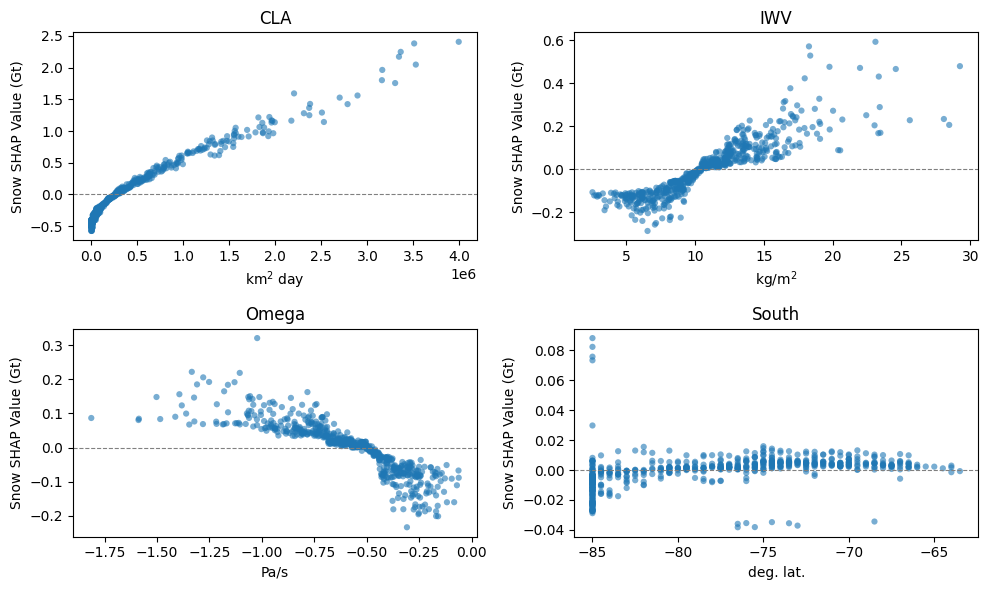

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
feature_lst = ['cumulative_landfalling_area', 'max_IWV_ais', 'avg_landfalling_minomega', 'max_south_extent']

for i, ax in enumerate(axes.flatten()):

    var = feature_lst[i]

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    plot_shap_dependence(shap_values[:,[4,3,2,5]], X_test, var, ax, feature_names=feature_lst,
        title=abbv, xlabel=units, ylabel='Snow SHAP Value (Gt)', zero_line=True, scatter_kwargs=None)

plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_1d_shap_subset.png', dpi=300)

Here, we plot each observation's SHAP value for each variable against their value of that variable. This shows the contribution, in aggregate, each variable makes to the observed snowfall prediction for the AR. Of course, CLA makes the biggest contributions to snowfall predictions, followed by IWV and then Omega.

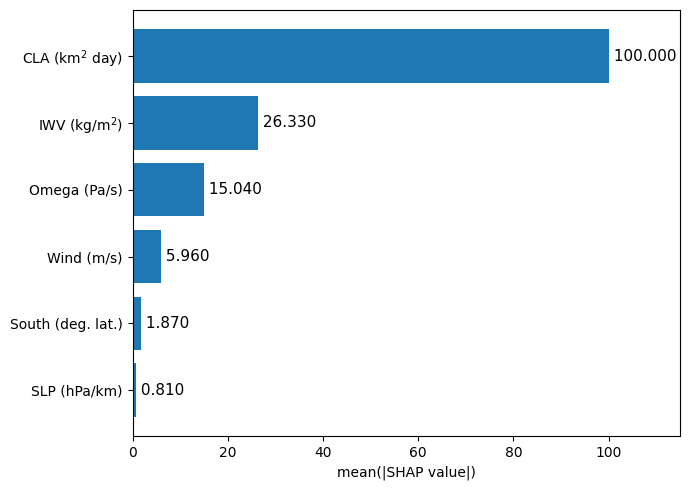

In [27]:
# make pretty tick labels!
tick_labels = []
for feat in X_test.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)

fig, ax = plt.subplots(figsize=(7, 5))
plot_shap_summary_bar(shap_values, ax, tick_labels=tick_labels, feature_names=X_test.columns, xlabel='mean(|SHAP value|)', normalize=True)
plt.tight_layout()

An example of a set of SHAP values for a particular storm (the one with the most snowfall in the training set). We see that CLA added 2.39 Gt to the snowfall prediction and IWV added about half a Gt. The omega value actually detracted from the prediction, likely because this storm had below average lifting.

Let's put together some of our plots down here.

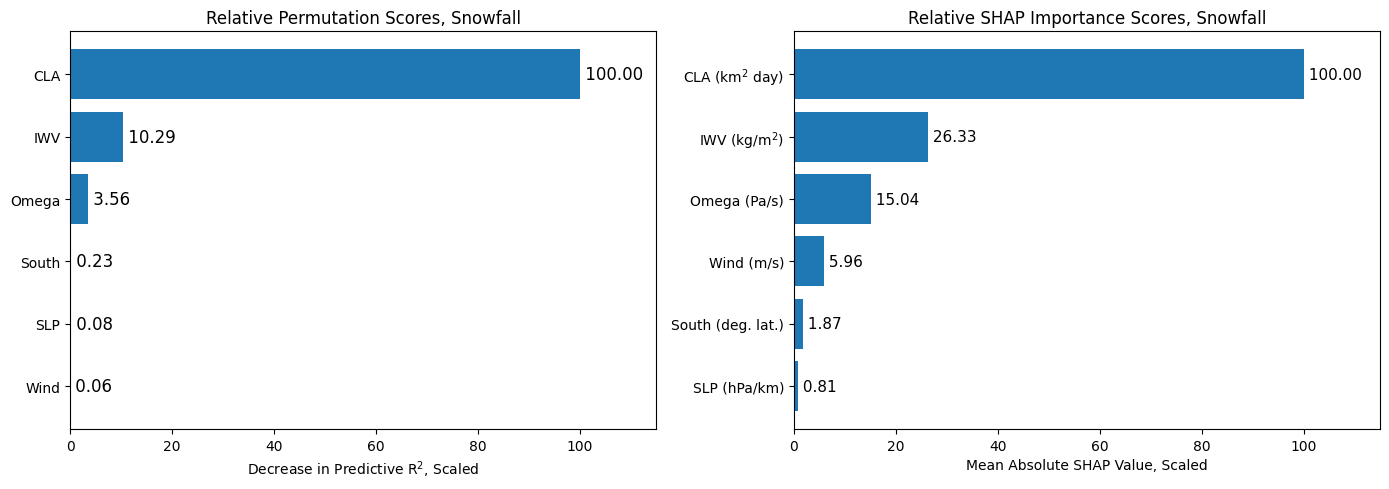

In [28]:
fig, axs = plt.subplots(figsize=(14,5), ncols=2, nrows=1)
tick_labels = [ABBV_DICT[varname] for varname in importances.index]
plot_variable_importance(importances, axs[0], 'Relative Permutation Scores, Snowfall', tick_labels=tick_labels)

tick_labels = []
for feat in X_test.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)
plot_shap_summary_bar(shap_values, axs[1], tick_labels=tick_labels, 
                      feature_names=X_test.columns, title='Relative SHAP Importance Scores, Snowfall', 
                      xlabel='Mean Absolute SHAP Value, Scaled', normalize=True,
                      label_fmt='{:.2f}')
plt.tight_layout()
plt.savefig('../outputs/plots/mean_snowfall_VI.png', dpi=300)

## Temperature

Now, let's look at the temperature outcomes for the mean model.

In [29]:
with open('../auxiliary_files/hyperparam_dictionaries/xgboost/best_temp_xgb.json', 'r') as file:
        best_temp = json.load(file)

In [30]:
best_temp

{'gamma': 4.0,
 'max_depth': 5.0,
 'reg_lambda': 0.01,
 'min_child_weight': 3.0,
 'subsample_frac': 0.3,
 'eta': 0.015,
 'num_boost': 272.0,
 'shrinkage_factor': 1.0187849998}

In [31]:
hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_temp['gamma'])
hyperparam_dict['max_depth'] = int(best_temp['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_temp['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_temp['min_child_weight'])
hyperparam_dict['subsample_frac'] = float(best_temp['subsample_frac'])
hyperparam_dict['eta'] = float(best_temp['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_temp['num_boost'])
shrinkage_factor = best_temp['shrinkage_factor']

In [32]:
train_data = pd.read_csv('../outputs/data_products/train.csv', index_col='Label')
test_data = pd.read_csv('../outputs/data_products/test.csv', index_col='Label')
y_col = 'max_T2M_anomaly_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
X_test = test_data[x_cols]
y_test = test_data[y_col]
y_train_centered = y_train - y_train.mean()

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

Let's fit the full temperature model now. This will be a bit easier than snowfall, since there's no linear model to consider.

In [33]:
model_temp = xgb.XGBRegressor(n_estimators=num_boost, 
                     max_depth=hyperparam_dict['max_depth'], 
                     learning_rate=hyperparam_dict['eta'],
                     booster=hyperparam_dict['booster'],
                     tree_method=hyperparam_dict['tree_method'],
                     gamma=hyperparam_dict['gamma'],
                     min_child_weight=hyperparam_dict['min_child_weight'],
                     reg_lambda=hyperparam_dict['reg_lambda'],
                     subsample=hyperparam_dict['subsample_frac'],
                     objective='reg:squarederror',
                     eval_metric='rmse',
                     random_state=54321)

temp_fit = model_temp.fit(X_train, y_train_centered)

Define the function to predict temperature given a fitted XGBoost model.

In [34]:
def prediction_temp(X, y_train, model_fit, shrinkage_factor, centered=False):
    pred = shrinkage_factor*(model_fit.predict(X))

    if not centered:
        return pred + y_train.mean()
    return pred

In [35]:
y_test_pred = prediction_temp(X_test, y_train, temp_fit, shrinkage_factor)
y_train_pred = prediction_temp(X_train, y_train, temp_fit, shrinkage_factor)

In [36]:
## training predictive r-squared
train_pred_r2 = predictive_r2(y_train_pred, y_train)

## testing predictive r-squared
test_pred_r2 = predictive_r2(y_test_pred, y_test)

## ols baseline
reg = LinearRegression().fit(X_train, y_train_centered)
y_pred_ols = reg.predict(X_test) + y_train.mean()
test_ols_r2 = predictive_r2(y_pred_ols, y_test)

In [37]:
train_res = train_pred_r2
train_res

np.float64(0.7150827486888082)

In [38]:
test_pred_r2

np.float64(0.5813605929343251)

In [39]:
test_ols_r2

np.float64(0.4941558269780386)

By what percentage did our xgboost model close the gap between perfection and OLS?

In [40]:
(test_pred_r2 - test_ols_r2)/(1-test_ols_r2)

np.float64(0.17239452504773725)

A bit smaller than before, but not bad! Using our more complex XGBoost model increased our prediction error on the heldout test set, and closed about 15% of the gap between the OLS results and a perfect predictor.

Now, let's get into interpreting our results.

In [41]:
importances = get_permutation_importance(lambda X: prediction_temp(X, y_train=y_train, model_fit=temp_fit, shrinkage_factor=shrinkage_factor),
                               X_test, y_test, predictive_r2, maximize=True, n_repeats=500, seed=12345)

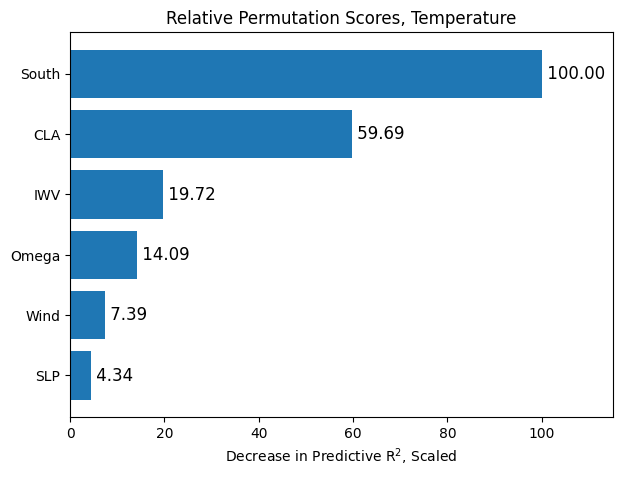

In [42]:
fig, ax = plt.subplots(figsize=(7,5))
tick_labels = [ABBV_DICT[varname] for varname in importances.index]
plot_variable_importance(importances, ax, 'Relative Permutation Scores, Temperature', tick_labels=tick_labels);

It seems like all of the variables play somewhat of a role now, much more so than cumulative snowfall at least. Instead, it seems the how far south the storm travels is the most important predictor. CLA is still somewhat important, followed by IWV, Omega and Wind. Once again, sea level pressure gradient is one of the lowest values.

Once again, we can start digging into our model predictive patterns via partial dependence plots. We show 1D PDPs first.

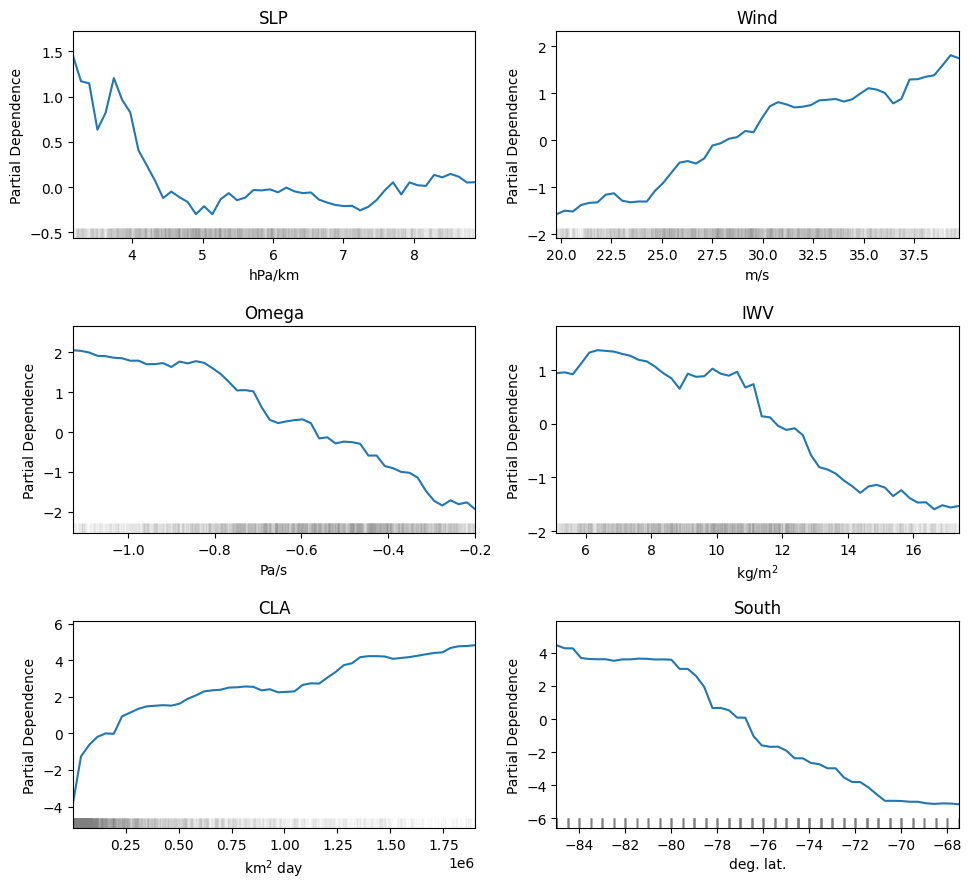

In [43]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 9))
axs = axs.flatten()
features = list(X_full.columns)

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train,
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)

    abbv = ABBV_DICT[features[i]]
    units = UNITS_DICT[features[i]]

    plot_pdp_1d(grid, pdp_vals, ax, feature_values=X_full[features[i]], title=abbv, xlabel=units,
        ylabel='Partial Dependence', xlim=None, rug=True);

plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_1d_pdp_full.png', dpi=300);

Let's make a plot of just southern extent and the three other atmospheric variables, since south will be our stand-in for geographic features. So, we'll be making similar plots as before, except instead of CLA our geographic variable will be southern extent.

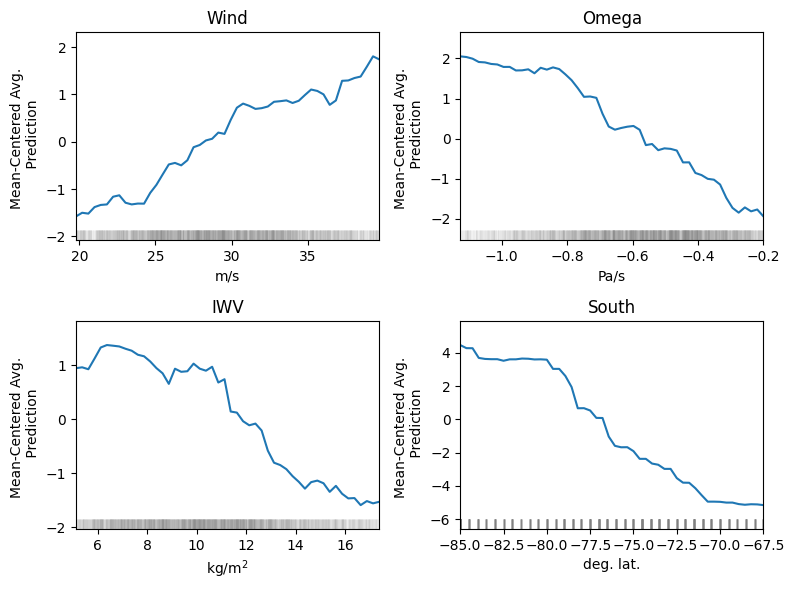

In [44]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))
axs = axs.flatten()
features = list(X_train.columns[[1, 2, 3, 5]])

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train,
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)
    abbv = ABBV_DICT[features[i]]
    units = UNITS_DICT[features[i]]

    plot_pdp_1d(grid, pdp_vals, ax, feature_values=X_full[features[i]], title=abbv, xlabel=units,
        ylabel='Mean-Centered Avg. \n Prediction', xlim=None, rug=True);

plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_1d_pdp_subset.png', dpi=300)

Interpretation: holding all other variables fixed, making an AR go further south on the continent increases temperature anomaly predictions to the greatest degree. It also seems like if you make a storm drier, then temperature anomaly predictions increase, as well as if you have more lifting. Increasing landfalling 850 hPa winds increases temperature predictions (with all other variables fixed), although much more modestly than the other variables.

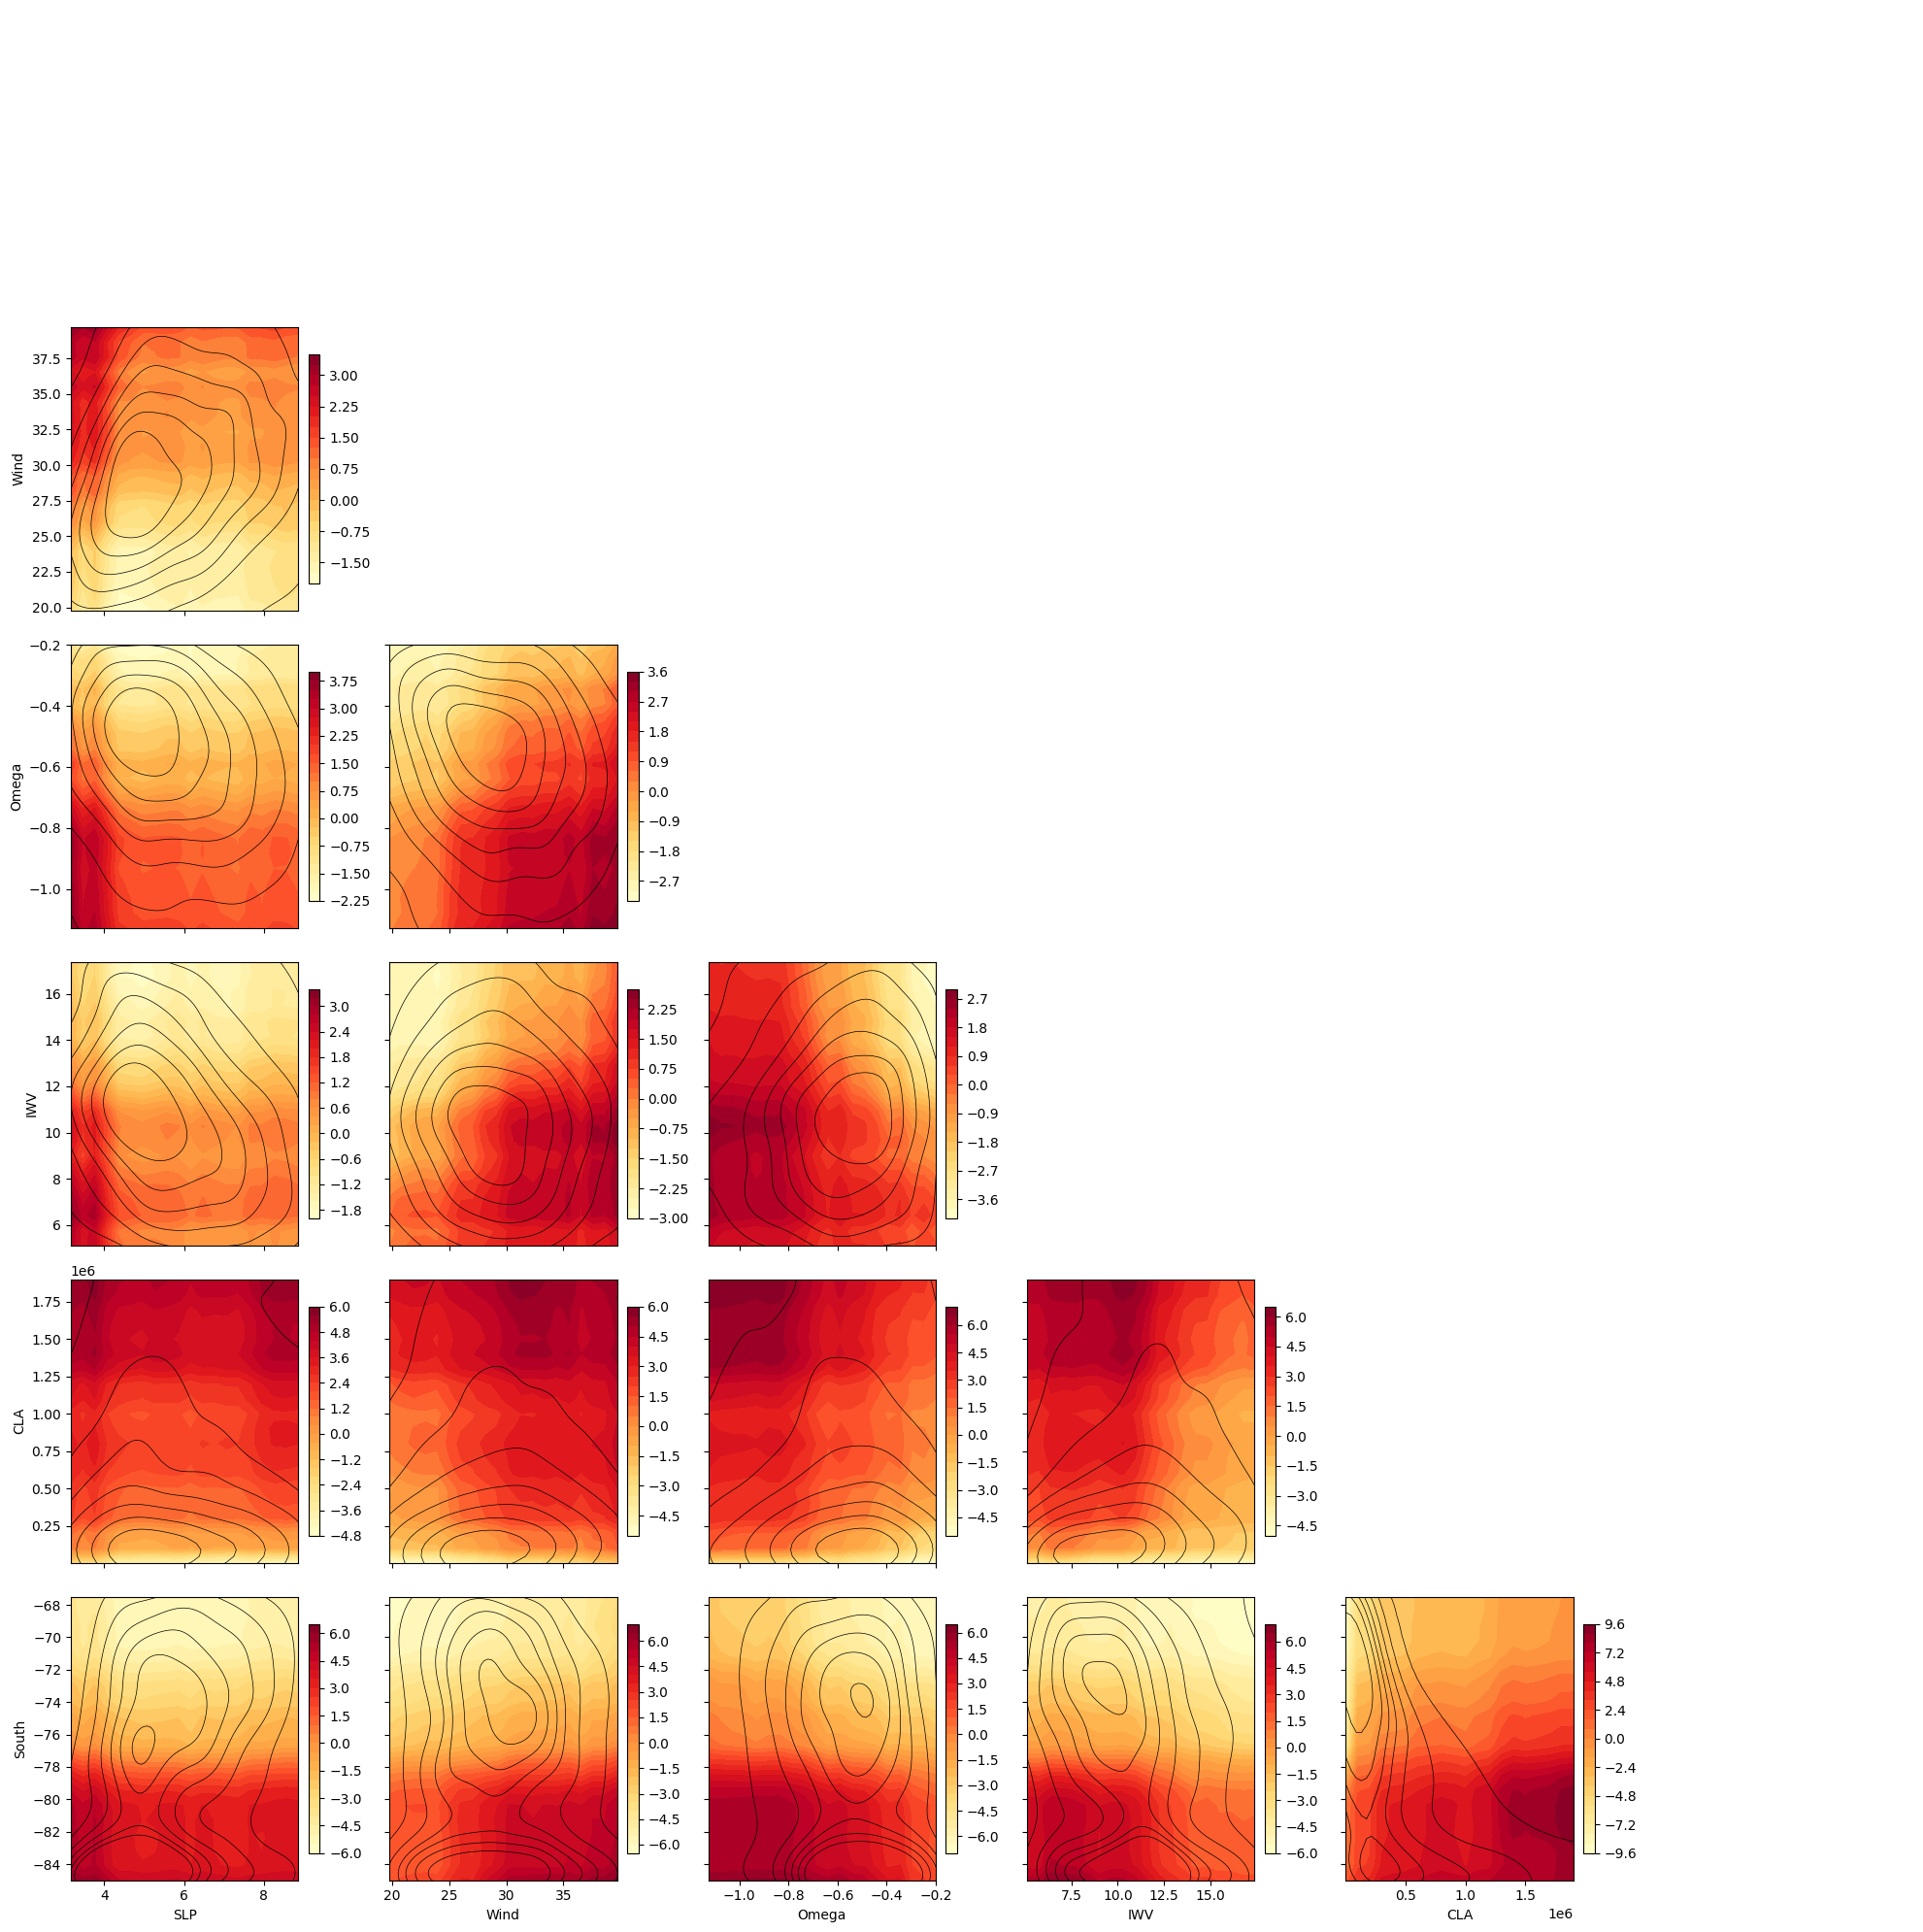

In [45]:
features = X_test.columns
n_features = len(features)

fig, axs = plt.subplots(ncols=n_features, nrows=n_features, figsize=(20, 20))

for i in range(n_features):
    for j in range(n_features):
        ax = axs[i, j]
        
        # Only plot on the lower diagonal (row index > col index)
        if i > j:
            feat_y = features[i]
            feat_x = features[j]

            q = 0.05 # quantile to clip data
            extents = [X_full[feat_x].quantile(q), 
                       X_full[feat_x].quantile(1-q),
                       X_full[feat_y].quantile(q),
                       X_full[feat_y].quantile(1-q)]

            grid1, grid2, pdp_matrix = compute_pdp_2d(
                feat_x, feat_y, 
                X_full, 
                lambda X: prediction_temp(X, 
                                          y_train=y_train, 
                                          model_fit=temp_fit,
                                          shrinkage_factor=shrinkage_factor,
                                          centered=True),
                extents=extents
            )
            
            ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full[feat_x],
                feat_y_values=X_full[feat_y], cmap='YlOrRd', levels=25, kde=True)

            fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

            # standardize labels: x only on bottom row, y only on left column
            if i == n_features - 1:
                ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])

        else:
            # Hide the upper diagonal and the diagonal itself
            ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_2d_pdp_full.png', dpi=300);

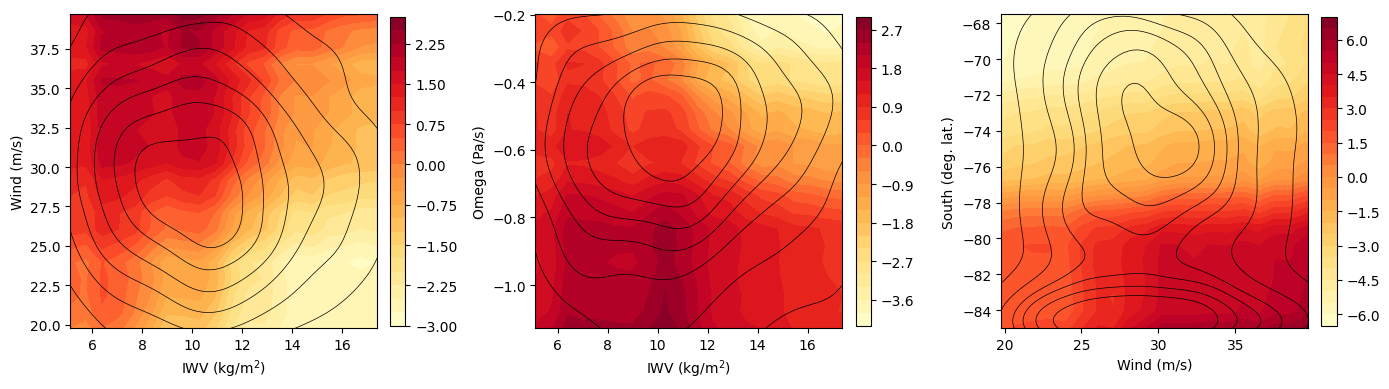

In [46]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(14, 4))

axs = axs.flatten()

combos = [('max_IWV_ais', 'max_landfalling_v850hPa'),
          ('max_IWV_ais', 'avg_landfalling_minomega'),
          ('max_landfalling_v850hPa', 'max_south_extent')]

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]

    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train, 
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)
    x_label = f'{ABBV_DICT[combo[0]]} ({UNITS_DICT[combo[0]]})'
    y_label = f'{ABBV_DICT[combo[1]]} ({UNITS_DICT[combo[1]]})'
    ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full[combo[0]],
                feat_y_values=X_full[combo[1]], xlabel=x_label, ylabel=y_label, cmap='YlOrRd', levels=25, kde=True)

    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout();

plt.savefig('../outputs/plots/mean_temp_2d_pdp_subset.png', dpi=300)

Interpretations:

+ Predicted temperature anomalies are much higher for wind-dominated ARs than moisture dominated ARs, holding all other variables constant.
+ Drier ARs with more lifting have higher temperature anomalies.
+ Southern extent plays a pretty significant role, but after a certain point it doesn't increase much further, and any further increases in predictions seem driven by wind-speed.

We also conduct a SHAP analysis as before.

In [47]:
def prediction_temp(X):
    X_df = pd.DataFrame(X, columns=FULL_FEATURE_NAMES)
    pred = y_train.mean() + shrinkage_factor*(temp_fit.predict(X_df))

    return pred

explainer_full = shap.KernelExplainer(
    model=prediction_temp,
    data=X_train
)
shap_values_temp = explainer_full.shap_values(X_test)

Using 2466 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 616/616 [04:55<00:00,  2.08it/s]


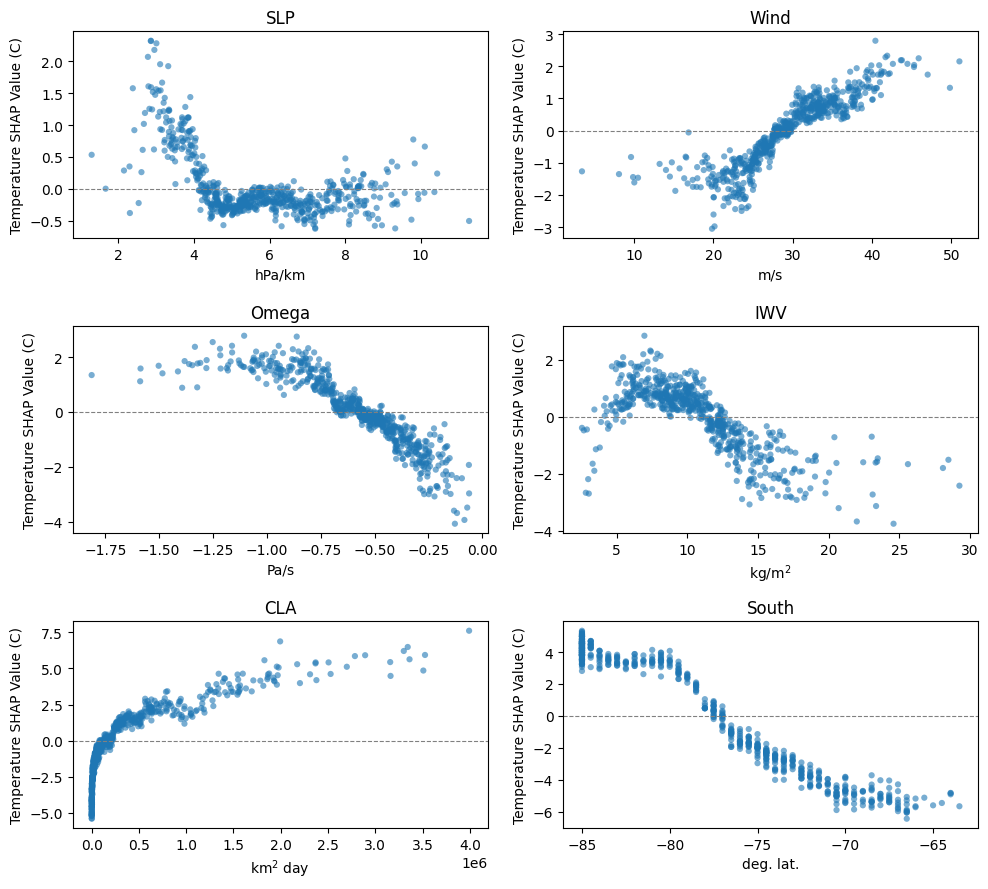

In [48]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
feature_lst = list(X_test.columns)

for i, ax in enumerate(axes.flatten()):

    var = feature_lst[i]

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    plot_shap_dependence(shap_values_temp, X_test, var, ax, feature_names=feature_lst,
        title=abbv, xlabel=units, ylabel='Temperature SHAP Value (C)', zero_line=True, scatter_kwargs=None)

plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_1d_shap_full.png', dpi=300);

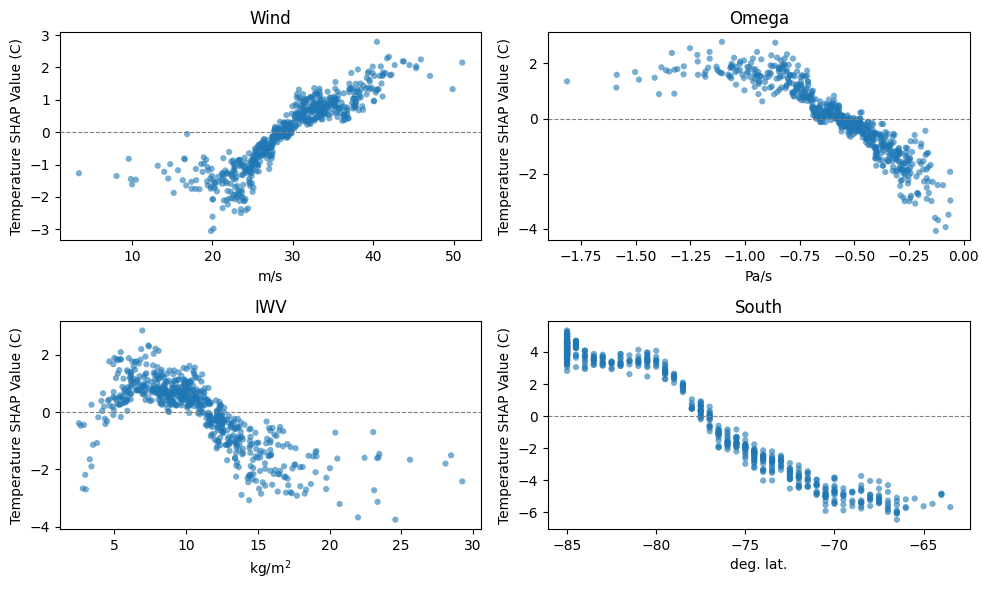

In [49]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
feature_lst = ['max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'max_south_extent']

for i, ax in enumerate(axes.flatten()):

    var = feature_lst[i]

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    plot_shap_dependence(shap_values_temp[:,[1,2,3,5]], X_test, var, ax, feature_names=feature_lst,
        title=abbv, xlabel=units, ylabel='Temperature SHAP Value (C)', zero_line=True, scatter_kwargs=None)

plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_1d_shap_subset.png', dpi=300)

There are some interesting nonlinearities and shapes present, for instance the shape of the SLP plot, the IWV plot for low IWV. Some interesting findings are that lower landfalling SLP seem to contribute pretty heftily towards positive predictions of temperature anomaly. Of course, how far south the storm traveled seems to contribute the most in general, with 6 degrees of the temperature anomalies being contributed as storms travel south. However, it's interesting that there's a flatline, where after 80 degrees latitude, there doesn't seem to be any greater contribution to the temperature anomaly. Similar with omega: at a certain point, there's no more greater contribution.

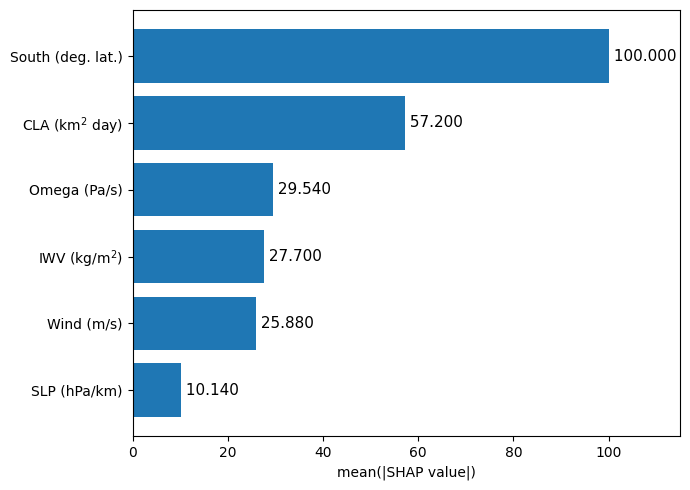

In [50]:
# make pretty tick labels!
tick_labels = []
for feat in X_test.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)

fig, ax = plt.subplots(figsize=(7, 5))
plot_shap_summary_bar(shap_values_temp, ax, tick_labels=tick_labels, feature_names=X_test.columns, xlabel='mean(|SHAP value|)', normalize=True)
plt.tight_layout()

Interesting! It seems omega and IWV switched roles.

Let's put together the variable importance metric plots for the paper.

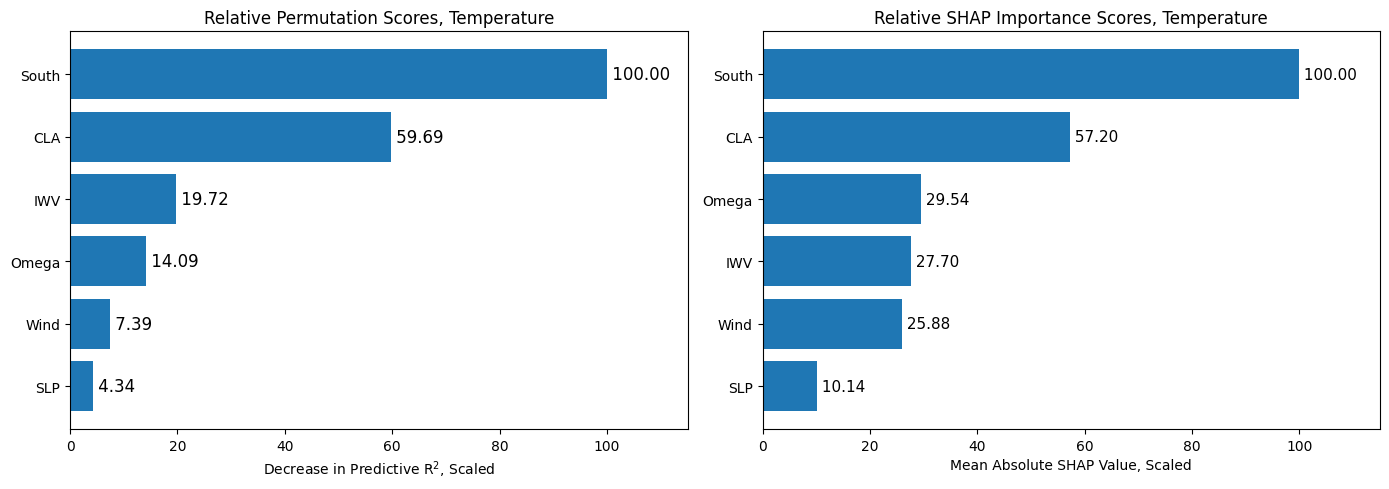

In [51]:
fig, axs = plt.subplots(figsize=(14,5), ncols=2, nrows=1)
tick_labels = [ABBV_DICT[varname] for varname in importances.index]
plot_variable_importance(importances, axs[0], 'Relative Permutation Scores, Temperature', tick_labels=tick_labels)

tick_labels = []
for feat in X_test.columns:
    abbv = ABBV_DICT.get(feat, feat)
    tick_labels.append(f'{abbv}' if units else abbv)
plot_shap_summary_bar(shap_values_temp, axs[1], tick_labels=tick_labels, 
                      feature_names=X_test.columns, title='Relative SHAP Importance Scores, Temperature', 
                      xlabel='Mean Absolute SHAP Value, Scaled', normalize=True,
                      label_fmt='{:.2f}')
plt.tight_layout()
plt.savefig('../outputs/plots/mean_temp_VI.png', dpi=300)